In [ ]:
Machine Learning using Python and PySpark.
Dataset: NYC Yellow Taxi Dataset (Recommended small sample for Colab):
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet


In [1]:
# Install PySpark and visualization libraries
!pip install pyspark seaborn matplotlib

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("NYC_Taxi_PySpark_ML") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark Session Created!")

Spark Session Created!


In [4]:
import requests

# NYC Taxi URL
taxi_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
local_path = "yellow_tripdata_2024-01.parquet"

print("Downloading NYC Taxi data... (this may take 30-60 seconds)")

response = requests.get(taxi_url, stream=True)
with open(local_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024*1024):
        f.write(chunk)

print("Download completed!")

# Now read the local Parquet file
df_taxi = spark.read.parquet(local_path).limit(100000)

print(f"NYC Taxi Dataset Loaded! Total rows: {df_taxi.count():,}")
df_taxi.show(5)
df_taxi.printSchema()

Download completed!
NYC Taxi Dataset Loaded! Total rows: 100,000
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-01-01 00:57:55|  2024-01-01 01:17:43|              1|         1.72|         1|                 N|         

In [5]:
# Data Cleaning
df_taxi = df_taxi.filter(F.col("fare_amount") > 0) \
                 .filter(F.col("trip_distance") > 0) \
                 .na.drop(subset=["fare_amount", "trip_distance"])
print("Data cleaning complete")

Data cleaning complete


In [6]:
# Create new feature: trip duration in minutes
df_taxi = df_taxi.withColumn("trip_duration_minutes",
                             (F.unix_timestamp("tpep_dropoff_datetime") -
                              F.unix_timestamp("tpep_pickup_datetime")) / 60)

# Select relevant columns
df_taxi = df_taxi.select(
    "fare_amount",
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "PULocationID",
    "DOLocationID"
)

print("Data cleaned and features created")
df_taxi.describe().show()

Data cleaned and features created
+-------+------------------+-----------------+---------------------+------------------+------------------+------------------+
|summary|       fare_amount|    trip_distance|trip_duration_minutes|   passenger_count|      PULocationID|      DOLocationID|
+-------+------------------+-----------------+---------------------+------------------+------------------+------------------+
|  count|             96778|            96778|                96778|             96778|             96778|             96778|
|   mean|21.728815846576992|4.287731405898119|   16.699385018633762| 1.498594721940937|159.87755481617722|159.32782243898407|
| stddev| 21.82145663652338|6.972907660327126|    45.80889815025733|0.9709946016143777| 63.52470471398323| 71.25616245940759|
|    min|              0.01|             0.01|   -6.066666666666666|                 0|                 1|                 1|
|    max|            1616.5|            971.8|   1438.9666666666667|                

In [7]:
# Define features
feature_cols = ["trip_distance", "trip_duration_minutes", "passenger_count", "PULocationID"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")

# Model
rf = RandomForestRegressor(
    featuresCol="scaled_features",
    labelCol="fare_amount",
    numTrees=50,
    maxDepth=10,
    seed=42
)
print("Defined features and model: complete")

Defined features and model: complete


In [10]:
from pyspark.ml import Pipeline   # ← This was missing

# Pipeline
pipeline = Pipeline(stages=[assembler, scaler, rf])

# Split data
train, test = df_taxi.randomSplit([0.8, 0.2], seed=42)

print("Pipeline and data split completed successfully!")

Pipeline and data split completed successfully!


In [11]:
# Train model
model = pipeline.fit(train)

# Make predictions
predictions = model.transform(test)

print("Model training and predictions completed")

Model training and predictions completed


In [12]:
# Model Evaluation
evaluator = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction")

rmse = evaluator.evaluate(predictions, {evaluator.metricName: "rmse"})
r2 = evaluator.evaluate(predictions, {evaluator.metricName: "r2"})

# testing icons in the printout
print(f"🎯 RMSE: ${rmse:.2f}")
print(f"🎯 R² Score: {r2:.4f}")


🎯 RMSE: $8.73
🎯 R² Score: 0.8242


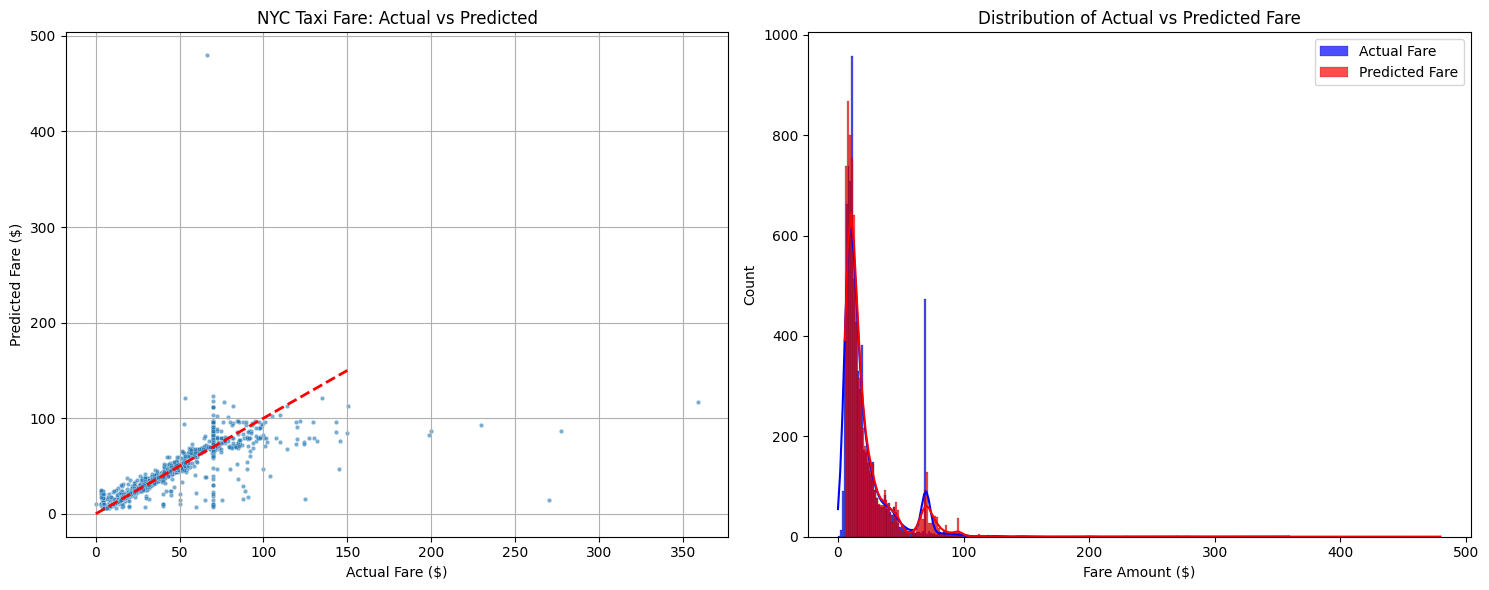

In [13]:
# Visualizations
# Convert to Pandas for plotting (sample for speed)
pred_pd = predictions.select("fare_amount", "prediction").toPandas().sample(8000, random_state=42)

plt.figure(figsize=(15, 6))

# Scatter Plot: Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=pred_pd['fare_amount'], y=pred_pd['prediction'], alpha=0.6, s=10)
plt.plot([0, 150], [0, 150], 'r--', linewidth=2)
plt.title('NYC Taxi Fare: Actual vs Predicted')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.grid(True)

# Distribution Plot
plt.subplot(1, 2, 2)
sns.histplot(pred_pd['fare_amount'], kde=True, color='blue', label='Actual Fare', alpha=0.7)
sns.histplot(pred_pd['prediction'], kde=True, color='red', label='Predicted Fare', alpha=0.7)
plt.title('Distribution of Actual vs Predicted Fare')
plt.xlabel('Fare Amount ($)')
plt.legend()

plt.tight_layout()
plt.show()

🔝 Top Feature Importances:
                 Feature  Importance
0          trip_distance    0.596324
1  trip_duration_minutes    0.328765
3           PULocationID    0.067819
2        passenger_count    0.007091


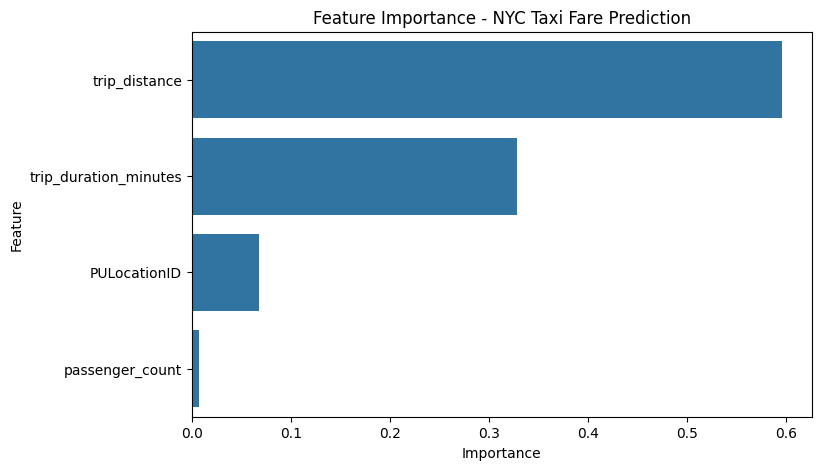

In [14]:
# Features
rf_model = model.stages[-1]
importances = rf_model.featureImportances.toArray()

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("🔝 Top Feature Importances:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance - NYC Taxi Fare Prediction')
plt.show()

In [15]:
# Save the model and predictions
# Save model
model.write().overwrite().save("nyc_taxi_fare_model")

# Save predictions (simple version)
predictions.select("fare_amount", "prediction").write.mode("overwrite").csv("taxi_predictions", header=True)

print("Model and predictions saved!")

Model and predictions saved!
